In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:\\Users\\merug\\Desktop\\Salary_Data[1].csv")

In [3]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [5]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [6]:
df["Education Level"].value_counts()

Education Level
Bachelor's Degree    2267
Master's Degree      1573
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

In [7]:
df["Age"]=df['Age'].fillna(int(df['Age'].mean()))

In [8]:
df['Age'].isnull().sum()

np.int64(0)

In [9]:
df['Gender'].value_counts()

Gender
Male      3674
Female    3014
Other       14
Name: count, dtype: int64

In [10]:
df['Gender']=df['Gender'].fillna("Female")

In [11]:
df['Gender'].isnull().sum()

np.int64(0)

In [12]:
df["Education Level"].value_counts()

Education Level
Bachelor's Degree    2267
Master's Degree      1573
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

In [13]:
df["Education Level"]=df["Education Level"].fillna("PhD")

In [14]:
df["Job Title"].value_counts()

Job Title
Software Engineer                 518
Data Scientist                    453
Software Engineer Manager         376
Data Analyst                      363
Senior Project Engineer           318
                                 ... 
Junior Social Media Specialist      1
Senior Software Architect           1
Developer                           1
Social M                            1
Social Media Man                    1
Name: count, Length: 193, dtype: int64

In [15]:
df["Job Title"]=df["Job Title"].fillna("Data Analyst")

In [16]:
df["Years of Experience"].isnull().sum()

np.int64(3)

In [17]:
df["Years of Experience"].mean()

np.float64(8.094687360095508)

In [18]:
df["Years of Experience"] =df["Years of Experience"].fillna(int(df["Years of Experience"].mean()))

In [19]:
df["Salary"].isnull().sum()

np.int64(5)

In [20]:
df["Salary"].mean()

np.float64(115326.96477086132)

In [21]:
df["Salary"] =df["Salary"].fillna(int(df["Salary"].mean()))

In [22]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

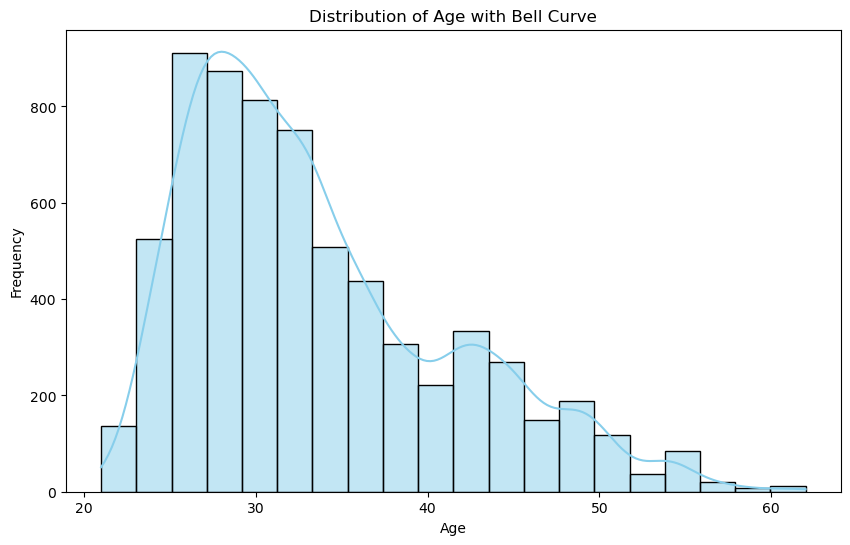

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='skyblue', bins=20)
plt.title('Distribution of Age with Bell Curve')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [24]:
q1=df['Age'].quantile(0.25)
q3=df['Age'].quantile(0.75)
IQR=q3-q1
lower_Age=q1-1.5*IQR
upper_Age=q3+1.5*IQR
print(f"Lower Bound: {lower_Age}, Upper Bound: {upper_Age}")

Lower Bound: 13.0, Upper Bound: 53.0


In [25]:
df_clean_Age=df[(df['Age']>= lower_Age) & (df['Age']<= upper_Age)]

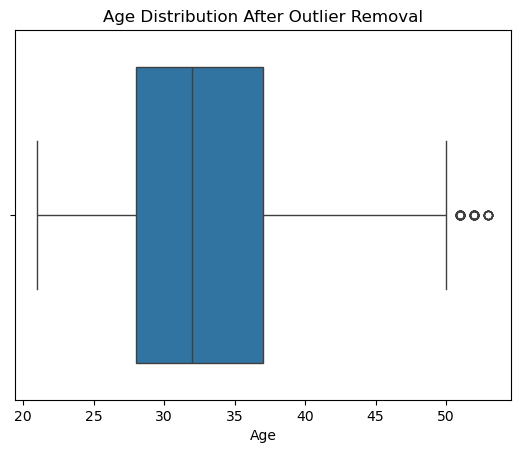

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_clean_Age['Age'])
plt.title('Age Distribution After Outlier Removal')
plt.show()

In [27]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean_Age.shape}")

Original shape: (6704, 6)
Cleaned shape: (6581, 6)


In [28]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

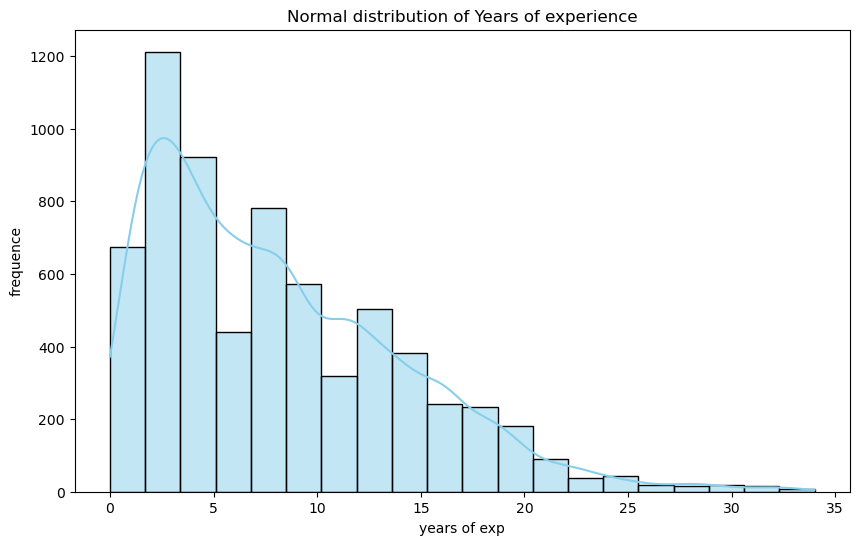

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(df['Years of Experience'],kde=True,color="skyblue",bins=20)
plt.title("Normal distribution of Years of experience")
plt.xlabel("years of exp")
plt.ylabel("frequence")
plt.show()

In [30]:
Q1=df["Years of Experience"].quantile(0.25)
Q3=df["Years of Experience"].quantile(0.75)
IQR=Q3-Q1
lower_exp=Q1-1.5*IQR
upper_exp=Q3+1.5*IQR

In [31]:
df_clean_year_of_exp=df[(df["Years of Experience"]>=lower_exp) & (df["Years of Experience"] <=upper_exp)]

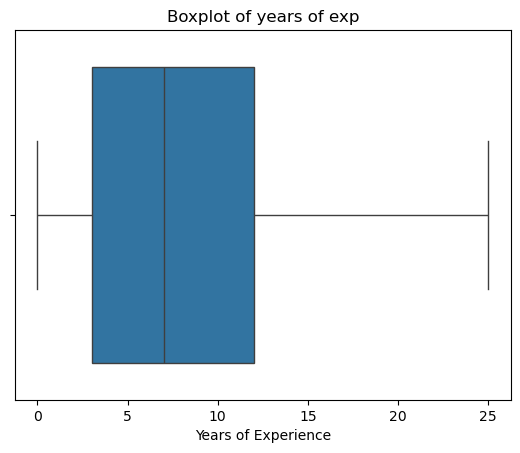

In [32]:
sns.boxplot(x=df_clean_year_of_exp["Years of Experience"])
plt.title("Boxplot of years of exp")
plt.show()


In [33]:
print("before removing",df.shape)
print("after removing",df_clean_year_of_exp.shape)

before removing (6704, 6)
after removing (6629, 6)


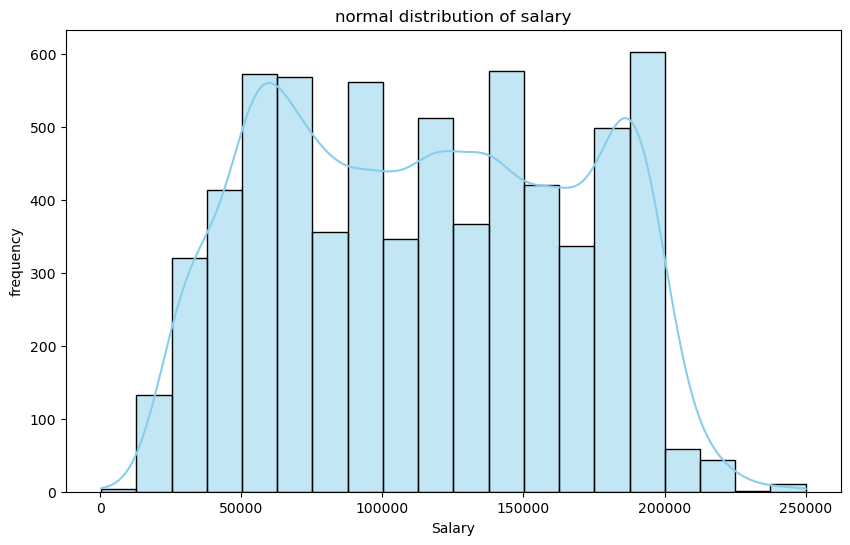

In [34]:
plt.figure(figsize=(10,6))
sns.histplot(df["Salary"],kde=True,color="skyblue",bins=20)
plt.title("normal distribution of salary")
plt.xlabel("Salary")
plt.ylabel("frequency")
plt.show()

In [35]:
Q1=df["Salary"].quantile(0.25)
Q3=df["Salary"].quantile(0.75)
IQR=Q3-Q1
lower_sal=Q1-1.5*IQR
upper_sal=Q3+1.5*IQR

In [36]:
df_clean_Salary=df[(df['Salary'] >=lower_sal ) & (df["Salary"] <=upper_sal)]

In [37]:
df_final = df[
    (df['Age'] >= lower_Age) & (df['Age'] <= upper_Age) &
    (df['Years of Experience'] >= lower_exp) & (df['Years of Experience'] <= upper_exp) &
    (df['Salary'] >= lower_sal) & (df['Salary'] <= upper_sal)
]

print(f"Rows remaining: {len(df_final)}")
print(df_final.head())

Rows remaining: 6556
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [38]:
df_final

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [39]:
df_final["Education Level"].value_counts()

Education Level
Bachelor's Degree    2254
Master's Degree      1553
PhD                  1262
Bachelor's            756
High School           442
Master's              288
phD                     1
Name: count, dtype: int64

In [40]:
df_final=df_final.copy()

In [41]:
df_final["Education Level"]=df_final["Education Level"].str.strip()
df_final["Education Level"]=df_final["Education Level"].replace("Bachelor's Degree","Bachelor's")
df_final["Education Level"]=df_final["Education Level"].replace("phD","PhD")
df_final["Education Level"]=df_final["Education Level"].replace("Master's Degree","Master's")

In [42]:
df_final["Education Level"].value_counts()

Education Level
Bachelor's     3010
Master's       1841
PhD            1263
High School     442
Name: count, dtype: int64

In [43]:
df_final["Job Title"].value_counts()

Job Title
Software Engineer                 518
Data Scientist                    453
Data Analyst                      365
Product Manager                   313
Senior Project Engineer           308
                                 ... 
Junior Social Media Specialist      1
Senior Software Architect           1
Developer                           1
Social M                            1
Social Media Man                    1
Name: count, Length: 193, dtype: int64

In [44]:
order={
    "High School":1,
    "Bachelor's":2,
    "Master's":3,
    "PhD":4
}
df_final['Education_Lvl'] = df_final['Education Level'].map(order)

In [45]:
df_final["Gender"]=df_final["Gender"].replace("Male",1)
df_final["Gender"]=df_final["Gender"].replace("Female",0)
df_final["Gender"]=df_final["Gender"].replace("Other",3)

C:\Users\merug\AppData\Local\Temp\ipykernel_8864\289395101.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final["Gender"]=df_final["Gender"].replace("Other",3)


In [46]:
df_final["Age"]=df_final["Age"].astype(int)
df_final["Years of Experience"]=df_final["Years of Experience"].astype(int)
df_final["Salary"]=df_final["Salary"].astype(int)
df_final["Gender"]=df_final["Gender"].astype(int)

In [47]:
df_final['Job Title'] = df_final['Job Title'].str.strip()  # removes leading/trailing spaces
df_final['Job Title'] = df_final['Job Title'].str.title()  # optional: standardizes capitalization

In [48]:
# 1. Define the grouping function
def simplify_job(title):
    title = str(title).lower()
    if any(keyword in title for keyword in ['software', 'developer', 'data', 'web', 'it', 'engineer', 'tech']):
        return 'Tech'
    elif any(keyword in title for keyword in ['manager', 'director', 'vp', 'ceo', 'chief', 'operations', 'lead']):
        return 'Management'
    elif any(keyword in title for keyword in ['sales', 'marketing', 'social', 'account', 'advertising']):
        return 'Sales_Marketing'
    elif any(keyword in title for keyword in ['hr', 'recruiter', 'human resources', 'admin', 'coordinator']):
        return 'HR_Admin'
    else:
        return 'Other'

# 2. Create the new column
df_final['Job_Group'] = df_final['Job Title'].apply(simplify_job)

# 3. Create Dummies for the NEW column
# drop_first=True prevents the Dummy Variable Trap
df_final = pd.get_dummies(df_final, columns=['Job_Group'], drop_first=True,dtype=int)

# 4. Drop the old messy column
df_final.drop('Job Title', axis=1, inplace=True)
df_final.drop('Education Level', axis=1, inplace=True)

In [49]:
df_final.head()

,Age,Gender,Years of Experience,Salary,Education_Lvl,Job_Group_Management,Job_Group_Other,Job_Group_Sales_Marketing,Job_Group_Tech
0,32,1,5,90000,2,0,0,0,1
1,28,0,3,65000,3,0,0,0,1
2,45,1,15,150000,4,1,0,0,0
3,36,0,7,60000,2,0,0,1,0
4,52,1,20,200000,3,1,0,0,0


In [50]:
X=df_final.drop("Salary",axis=1)
Y=df_final["Salary"]

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [52]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

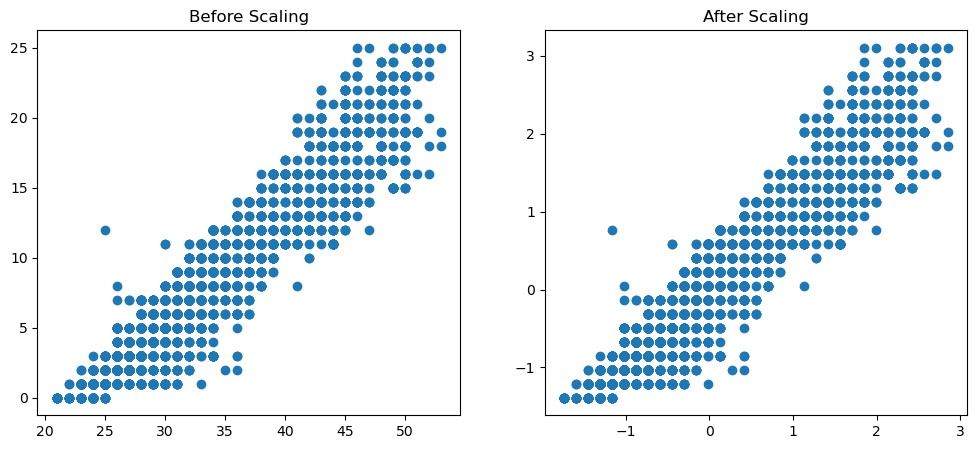

In [55]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.scatter(X_train['Age'], X_train['Years of Experience'])
ax1.set_title("Before Scaling")

# After Scaling
ax2.scatter(X_train_scaled['Age'], X_train_scaled['Years of Experience'])
ax2.set_title("After Scaling")

plt.show()

In [68]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled,Y_train)

scores = cross_val_score(model, X_train_scaled, Y_train, cv=5, scoring='r2')

print(scores)            # scores of each fold
print(scores.mean()) 
train=model.score(X_train_scaled,Y_train)
test=model.score(X_test_scaled,Y_test)
print("Train score:",train)
print("Test score:",test)# average score

[0.73198682 0.77611464 0.75988095 0.76159741 0.76328229]
0.7585724206624299
Train score: 0.7600893727752287
Test score: 0.7603370360235691


In [75]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# create polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train_scaled)

# model
model = LinearRegression()

# cross validation
scores = cross_val_score(model, X_poly, Y_train, cv=5, scoring='r2')

print(scores)
print(scores.mean())

[0.79480433 0.83712132 0.82301471 0.84034496 0.82914748]
0.8248865604923225


In [76]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

model = Ridge(alpha=1.0)
model.fit(X_train_scaled,Y_train)

scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='r2')
train=model.score(X_train_scaled,Y_train)
test=model.score(X_test_scaled,Y_test)
print("Train score:",train)
print("Test score:",test)

print(scores)
print(scores.mean())

Train score: 0.760088679806962
Test score: 0.7603625672309914
[0.73195406 0.77610229 0.75985389 0.76159676 0.76334494]
0.758570389160676


In [77]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score

model = Lasso(alpha=1.0)
model.fit(X_train_scaled,Y_train)
scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='r2')
train=model.score(X_train_scaled,Y_train)
test=model.score(X_test_scaled,Y_test)
print("Train score:",train)
print("Test score:",test)


print(scores)
print(scores.mean())

Train score: 0.7600893355777226
Test score: 0.7603440333955288
[0.73198117 0.77610632 0.75987594 0.76160086 0.7632979 ]
0.7585724379819935


In [78]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=1.0, l1_ratio=0.5)
model.fit(X_train_scaled,Y_train)
scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='r2')
train=model.score(X_train_scaled,Y_train)
test=model.score(X_test_scaled,Y_test)
print("Train score:",train)
print("Test score:",test)


print(scores)
print(scores.mean())

Train score: 0.6882983660584182
Test score: 0.6967379334509516
[0.70363686 0.75031833 0.73027952 0.74021092 0.73400885]
0.7316908953948376
